In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
import matplotlib.pyplot as plt

In [2]:
air = pd.read_csv('airquality.csv')

In [3]:
air.shape

(153, 7)

In [4]:
air.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,NaN,NaN,14.3,56,5,5


In [5]:
air.count()

Unnamed: 0    153
Ozone         116
Solar.R       146
Wind          153
Temp          153
Month         153
Day           153
dtype: int64

In [6]:
# check how many missing (null) values are in each column of your dataset.
air.isnull().sum()

Unnamed: 0     0
Ozone         37
Solar.R        7
Wind           0
Temp           0
Month          0
Day            0
dtype: int64

In [7]:
# summary statistics for all numerical columns.
air.describe()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
count,153.000000,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,77.000000,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,44.311398,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,39.000000,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,77.000000,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,115.000000,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,153.000000,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


In [8]:
# Remove missing data
A = air.dropna()
A.shape

(111, 7)

In [9]:
# Replace missing values
A = air.fillna(0)
A.shape

(153, 7)

In [10]:
# Fill missing values using the previous (above) value (Forward Fill)
A = air.ffill()
A.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,18.0,313.0,14.3,56,5,5


In [11]:
# Fill missing values using the next (below) value (Backward Fill)
A = air.bfill()
A.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,28.0,299.0,14.3,56,5,5


In [12]:
# fill missing values for multiple columns at once with MEDIAN
A = air['Ozone'].replace(np.nan,air['Ozone'].median())
A.head()

0    41.0
1    36.0
2    12.0
3    18.0
4    31.5
Name: Ozone, dtype: float64

In [13]:
imp = SimpleImputer(missing_values=np.nan,strategy='mean')
A = imp.fit_transform(air)
A

array([[  1.,  41., 190., ...,  67.,   5.,   1.],
       [  2.,  36., 118., ...,  72.,   5.,   2.],
       [  3.,  12., 149., ...,  74.,   5.,   3.],
       ...,
       [151.,  14., 191., ...,  75.,   9.,  28.],
       [152.,  18., 131., ...,  76.,   9.,  29.],
       [153.,  20., 223., ...,  68.,   9.,  30.]], shape=(153, 7))

In [14]:
# Convert back to DataFrame (Column names are restored)
A = pd.DataFrame(A, columns=air.columns)
A.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1.0,41.00000,190.000000,7.4,67.0,5.0,1.0
1,2.0,36.00000,118.000000,8.0,72.0,5.0,2.0
2,3.0,12.00000,149.000000,12.6,74.0,5.0,3.0
3,4.0,18.00000,313.000000,11.5,62.0,5.0,4.0
4,5.0,42.12931,185.931507,14.3,56.0,5.0,5.0


In [15]:
# Standard Scaling
# This rescales data so it has a Mean of 0 and Standard Deviation of 1

scaler = StandardScaler()
B = scaler.fit_transform(A)
print("Standard Scaled Data Statistics:")
print(pd.DataFrame(B).describe())

Standard Scaled Data Statistics:
                  0             1             2             3             4  \
count  1.530000e+02  1.530000e+02  1.530000e+02  1.530000e+02  1.530000e+02   
mean   9.288140e-17 -2.322035e-17 -1.741526e-17 -2.322035e-17  7.430512e-16   
std    1.003284e+00  1.003284e+00  1.003284e+00  1.003284e+00  1.003284e+00   
min   -1.720767e+00 -1.438115e+00 -2.040912e+00 -2.351584e+00 -2.319450e+00   
25%   -8.603835e-01 -7.388013e-01 -7.520217e-01 -7.283322e-01 -6.235080e-01   
50%    0.000000e+00  0.000000e+00  9.203008e-02 -7.333578e-02  1.184665e-01   
75%    8.603835e-01  1.353414e-01  7.992086e-01  4.392701e-01  7.544446e-01   
max    1.720767e+00  4.401158e+00  1.688885e+00  3.059256e+00  2.026401e+00   

                5             6  
count  153.000000  1.530000e+02  
mean     0.000000 -6.966105e-17  
std      1.003284  1.003284e+00  
min     -1.411916 -1.675504e+00  
25%     -0.703643 -8.832458e-01  
50%      0.004629  2.219211e-02  
75%      0.712902

In [16]:
#Min-Max Scaling  
# This rescales data to a fixed range, usually between 0 and 1

scaler = MinMaxScaler()
B = scaler.fit_transform(A)
print("\nMin-Max Scaled Data Statistics:")
print(pd.DataFrame(B).describe())


Min-Max Scaled Data Statistics:
                0           1           2           3           4           5  \
count  153.000000  153.000000  153.000000  153.000000  153.000000  153.000000   
mean     0.500000    0.246283    0.547191    0.434606    0.533716    0.498366   
std      0.291522    0.171817    0.268992    0.185421    0.230860    0.354131   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.250000    0.119760    0.345566    0.300000    0.390244    0.250000   
50%      0.500000    0.246283    0.571865    0.421053    0.560976    0.500000   
75%      0.750000    0.269461    0.761468    0.515789    0.707317    0.750000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

                6  
count  153.000000  
mean     0.493464  
std      0.295484  
min      0.000000  
25%      0.233333  
50%      0.500000  
75%      0.733333  
max      1.000000  


In [17]:
# Binarization
# Any value > 0.5 becomes 1, and any value <= 0.5 becomes 0

bin_model = Binarizer(threshold=0.5)
B_binary = bin_model.fit_transform(B)
print("\nBinarized Data Table:")
print(pd.DataFrame(B_binary))


Binarized Data Table:
       0    1    2    3    4    5    6
0    0.0  0.0  1.0  0.0  0.0  0.0  0.0
1    0.0  0.0  0.0  0.0  0.0  0.0  0.0
2    0.0  0.0  0.0  1.0  0.0  0.0  0.0
3    0.0  0.0  1.0  1.0  0.0  0.0  0.0
4    0.0  0.0  1.0  1.0  0.0  0.0  0.0
..   ...  ...  ...  ...  ...  ...  ...
148  1.0  0.0  1.0  0.0  0.0  1.0  1.0
149  1.0  0.0  0.0  1.0  1.0  1.0  1.0
150  1.0  0.0  1.0  1.0  0.0  1.0  1.0
151  1.0  0.0  0.0  0.0  0.0  1.0  1.0
152  1.0  0.0  1.0  1.0  0.0  1.0  1.0

[153 rows x 7 columns]


In [18]:
# --- 3. Model Building (Linear Regression) ---


#Splitting the dataset
train, test = train_test_split(A, test_size = 0.20)

In [19]:
len(train)

122

In [20]:
len(test)

31

In [21]:
X=A['Ozone'].values
X=X.reshape(-1,1)
Y = A['Temp']

In [22]:
model = LinearRegression()
model.fit(X,Y)
model.score(X,Y)*100

# Prediction: Predicting Temp if Ozone level is 128
prediction = model.predict([[128]])
print(f"Predicted Temp for Ozone 128: {prediction[0]}")

Predicted Temp for Ozone 128: 95.12601985515818


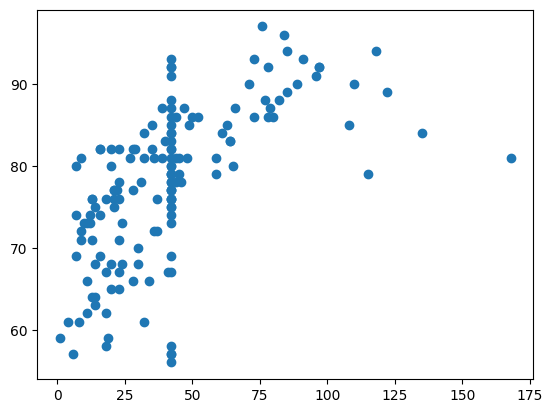

In [23]:
plt.scatter(X,Y)

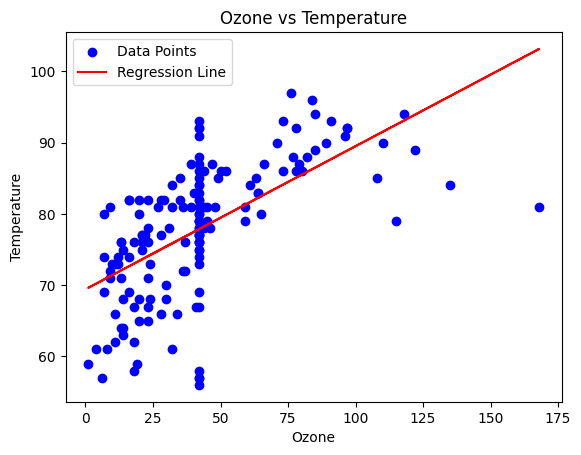

In [24]:
# --- 4. Visualization ---
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Regression Line') # Adding the best-fit line
plt.xlabel('Ozone')
plt.ylabel('Temperature')
plt.title('Ozone vs Temperature')
plt.legend()
plt.show()